<a href="https://colab.research.google.com/github/negativespace-exe/Machine-Learning/blob/main/CS_6600_Assignment_5_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS-6600 Assignment 5 - Clustering

**Rachel Wiggins**

*Weber State University*

In [16]:
#Our standard data science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# SciPy & Scikit-Learn imports
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import cut_tree
from scipy.cluster.hierarchy import dendrogram

# Some plotting settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## The Spotify Audio Features Dataset

For this assignment we'll be working with the Spotify audio features dataset. This dataset is a collection of musical and acoustic metrics originally computed by Spotify's internal audio analysis engines (derived from The Echo Nest, an audio intelligence company Spotify acquired in 2014). Rather than working with raw .mp3 or .wav audio waveforms, Spotify ran machine learning and digital signal processing models over its track catalog to quantify perceptual characteristics of songs (like "danceability" or "energy") on normalized numerical scales.

You can find more about the dataset (or download it yourself, if desired) [here](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset?resource=download). A deeper dive into the data can be found [here](https://medium.com/@mansisu08/spotify-tracks-dataset-abf6d02cdc49).

I've got the dataset stored on my Google Drive. The code below sets the URL for downloading and then imports the data as a Pandas dataframe.

In [2]:
url = 'https://drive.google.com/uc?export=download&id=11XTWCXwqz6P2zV7u8b0u1mnmSnKHDjcB'
df_music = pd.read_csv(url)

In [3]:
df_music.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


That's a lot of columns. The data dictionary (from the [Kaggle download website](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset?resource=download)) explains these columns as:

###**Data Dictionary**

* **duration_ms**: The track length in milliseconds.

* **explicit**: Whether or not the track has explicit lyrics (true = yes it does; false = no it does not OR unknown).

* **danceability**: Danceability describes how suitable a track is for dancing based on a combination of musical elements including tempo, rhythm stability, beat strength, and overall regularity. A value of 0.0 is least danceable and 1.0 is most danceable.

* **energy**: Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale.

* **key**: The key the track is in. Integers map to pitches using standard Pitch Class notation. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1.

* **loudness**: The overall loudness of a track in decibels (dB).

* **mode**: Mode indicates the modality (major or minor) of a track, the type of scale from which its melodic content is derived. Major is represented by 1 and minor is 0.

* **speechiness**: Speechiness detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g. talk show, audio book, poetry), the closer to 1.0 the attribute value. Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech, either in sections or layered, including such cases as rap music. Values below 0.33 most likely represent music and other non-speech-like tracks.

* **acousticness**: A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic.

* **instrumentalness**: Predicts whether a track contains no vocals. "Ooh" and "aah" sounds are treated as instrumental in this context. Rap or spoken word tracks are clearly "vocal". The closer the instrumentalness value is to 1.0, the greater likelihood the track contains no vocal content.

* **liveness**: Detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides strong likelihood that the track is live.

* **valence**: A measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry).

* **tempo**: The overall estimated tempo of a track in beats per minute (BPM). In musical terminology, tempo is the speed or pace of a given piece and derives directly from the average beat duration.

* **time_signature**: An estimated time signature. The time signature (meter) is a notational convention to specify how many beats are in each bar (or measure). The time signature ranges from 3 to 7 indicating time signatures of 3/4, to 7/4.

* **track_genre**: The genre in which the track belongs.

That's a lot of columns. Probably too many. Let's restrict to just the ones that are numeric measures.

In [4]:
feature_cols = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'valence', 'tempo'
]

X_raw = df_music[feature_cols]

We mentioned at the end of our lecture on clustering that it can be very dependent on scaling. Many of the derived measures like "danceability" or "speechiness" are on a 0 to 1 scale, but things like tempo can be much higher. This can be a problem. So, let's use the [Standard Scalar](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) transformation from sklearn that scales everything so it has mean 0 and standard deviation 1.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

We can convert back to a dataframe to examine the transformed dataset.

In [6]:
df_music_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
df_music_scaled.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,valence,tempo
0,0.629244,-0.717148,0.300828,0.551848,-0.850202,-0.504109,0.929306,-1.141863
1,-0.845908,-1.889980,-1.784744,-0.078993,1.831732,-0.504094,-0.798690,-1.489717
2,-0.742186,-1.122669,-0.293288,-0.273826,-0.315499,-0.504112,-1.365688,-1.528312
3,-1.733304,-2.312994,-2.039252,-0.457309,1.774593,-0.503883,-1.276974,1.987859
4,0.295030,-0.788711,-0.282750,-0.303145,0.463399,-0.504112,-1.184403,-0.073348


## Determining the number of clusters

The number of clusters, $k$, used for $k$-means clustering is a *hyperparameter*, which means its a value about the model that is set before training begins, not as a result of training. So, how might we determine what $k$ to use?

One way to do this is via the *elbow method*, which looks at the *inertia* of the clusters (the within cluster sum of squares). This is a measure of how far each observation is from its cluster's centroid.

$$\sum_{j = 1}^{k} \sum_{x_{i} \in C_{i}} ||x_{i} - \mu_{i}||^{2}$$

Now, this value will be strictly decreasing with the number of clusters. If there's only one cluster, then there will (probably) be a lot of observations far away from that cluster's centroid, and the inertia will be high. On the other hand if there are $N$ observations and there are $N$ clusters (the maximum number of clusters) then the inertia will be $0$. So, we can't just minimize it. If that were the goal, we'd always go with $N$ clusters. Instead, we want to see if we can find a point at which the intertia doesn't improve much with additional clusters.

We can do this by plotting the intertia values for different values of $k$, and identifying where we see an "elbow" in the chart.

The location of an elbow is subjective, and isn't always obvious. Such is life.

One way we can attempt to balance, if not eliminate, the subjective nature of this determination is by combining the elbow method with *silhouette analysis*. This analysis combines measuring how closely packed the elements are within a cluster, along with a measurement of how far the clusters are from each other. Good clusters should be both closely packed within themselves and clearly differentiated from each other.

Mathematically, the Silhouette Coefficient $s(i)$ is calculated using two distance metrics:

1. $a(i)$ **Intra-Cluster Distance**: The average Euclidean distance between sample $i$ and all other points within the same cluster. This measures cluster compactness (lower is better).

2. $b(i)$ **Nearest-Cluster Distance**: The average Euclidean distance between sample $i$ and all points in the nearest neighboring cluster. This measures cluster separation (higher is better).

The silhouette score for sample $i$ is defined as:

$$s(i) = \frac{b(i)-a(i)}{max(a(i),b(i))}$$

If this score is close to $1$, then the point is close to its own cluster and far from the nearest neighbor cluster. This is good. If the score is close to $0$ then the point sits close to the decision boundary between its cluster and the nearest neighbor cluster. If the score is negative, then on average the point is closer to its nearest neighbor cluster than its own, and is likely misclassified.

To get an overall measure based on the silhouette score, we can calculate the mean silhouette score for a given clustering:

$$\frac{1}{N}\sum_{i = 1}^{N}s(i)$$

We can plot this for different values of $k$, and see which value is maximal.

The inertia of a clustering is calculated automatically by the $k$-means algorithm in sklearn, and included as an attribute of the $k$-means object. It can be accessed with *kmeans.inertia_* (where *kmeans* is whatever the name of the object is).

The silhouette score is a [function available](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html) from sklearn's *metrics* library.

**WARNING** - The running time of the silhouette score is $O(N^{2})$, where $N$ is the number of observations. If you have a very large number of observations (like we do with the Spotify audio features dataset) this can be prohibitively long.

Let's combine the elbow method and silhouette analysis to investigate a demo dataset similar to the one we constructed in our clustering lecture, but with $3$ clusters instead of $2$.

In [7]:
np.random.seed(6600);
X_demo = np.random.standard_normal((150,2));
X_demo[:50,0] += 3;
X_demo[:50,1] -= 4;
X_demo[50:100,0] -= 3;
X_demo[50:100,1] += 4;

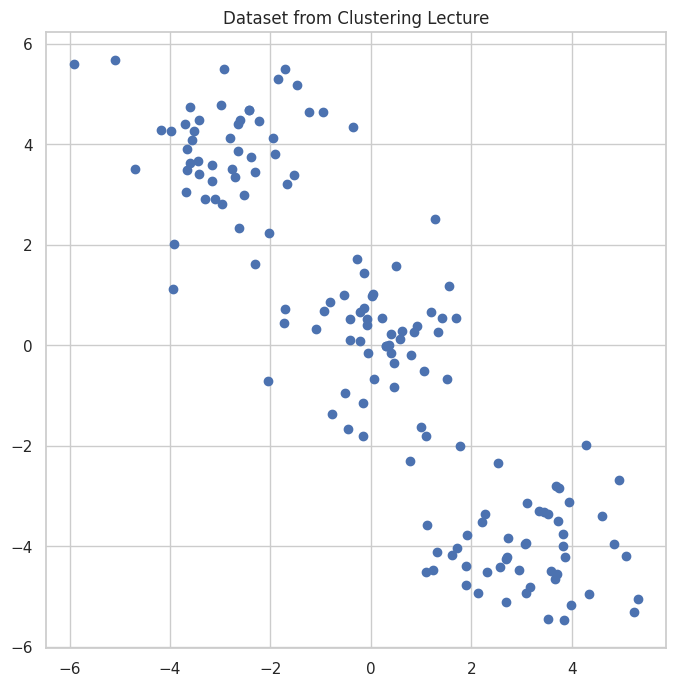

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax.scatter(X_demo[:,0], X_demo[:,1])
ax.set_title("Dataset from Clustering Lecture");

Let's run $k$ means clustering on this for different values of $k$ from $2$ to $10$, and go through elbow and silhouette analysis.

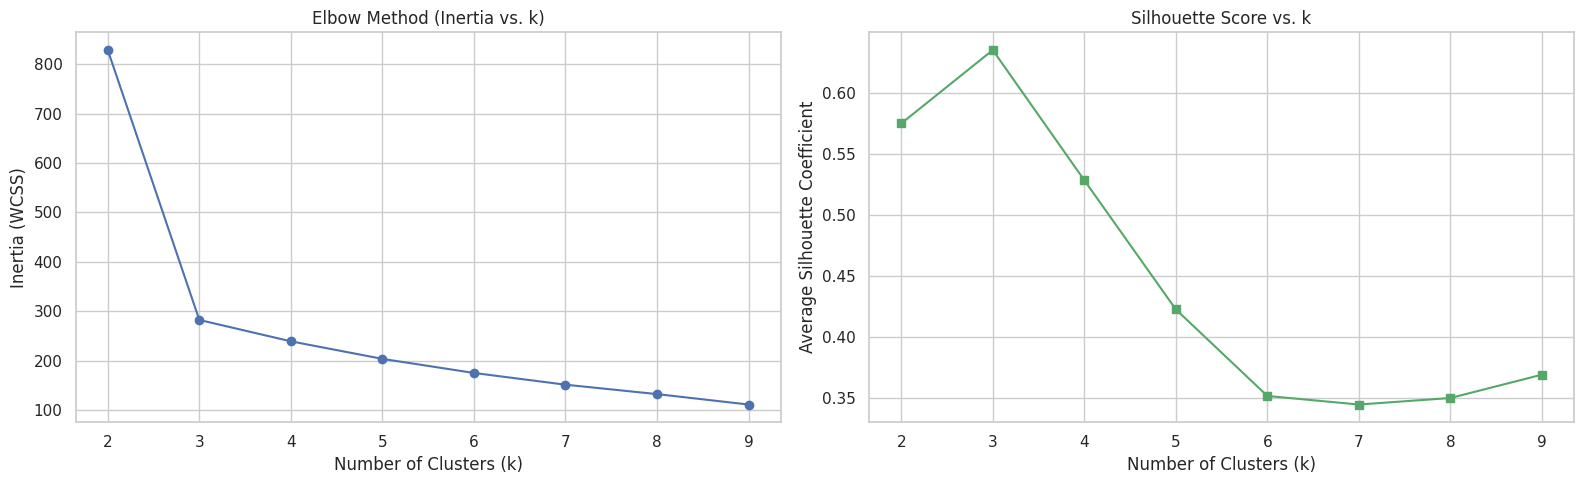

In [9]:
# Range of k values to test
k_range = range(2, 10)

inertia_list = []
silhouette_list = []

for k in k_range:
    # Initialize KMeans with n_clusters=k, random_state=6600, and n_init=10
    kmeans = KMeans(n_clusters=k, random_state=6600, n_init=10)

    # Fit model on X_demo and predict cluster labels
    labels = kmeans.fit_predict(X_demo)

    # Append the inertia_ attribute to inertia_list
    inertia_list.append(kmeans.inertia_)

    # Compute silhouette_score(X_demo, labels) and append to silhouette_list
    score = silhouette_score(X_demo, labels)
    silhouette_list.append(score)

# Plotting the diagnostic curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Elbow Curve (Inertia)
axes[0].plot(k_range, inertia_list, marker='o', color='b')
axes[0].set_title("Elbow Method (Inertia vs. k)")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (WCSS)")

# Plot 2: Silhouette Scores
axes[1].plot(k_range, silhouette_list, marker='s', color='g')
axes[1].set_title("Silhouette Score vs. k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Average Silhouette Coefficient")

plt.tight_layout()
plt.show()

It looks like the ideal number of clusters would be $3$. Which is good, because that's how this dataset was built.

## Your Spotify Songs Analysis

Now it's your turn. Suppose you want to put together some clusters of songs based upon the Spotify songs dataset. However, that dataset is too large for silhouette analysis to be practical. So, let's randomly sample 15,000 songs from it.

In [10]:
X_sample = df_music_scaled.sample(15000, random_state=6600).reset_index(drop=True)

In [11]:
X_sample.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,valence,tempo
0,-0.713375,-1.098815,-0.709846,-0.502706,0.833300,-0.488476,-0.293405,0.367207
1,-1.047589,0.563028,1.138517,1.403057,-0.946228,1.014204,1.650590,1.819769
2,0.122161,-1.901907,-1.038320,-0.478116,1.867820,-0.504112,0.327593,-1.629353
3,-0.892006,-1.186281,-0.171801,-0.182084,1.672344,-0.504050,-0.991546,-1.247173
4,-0.263914,-1.098815,-0.527913,-0.500815,0.935549,-0.465346,-0.578833,0.721900


Run elbow and silhouette analysis on X_sample like we did above. How many clusters would you recommend?

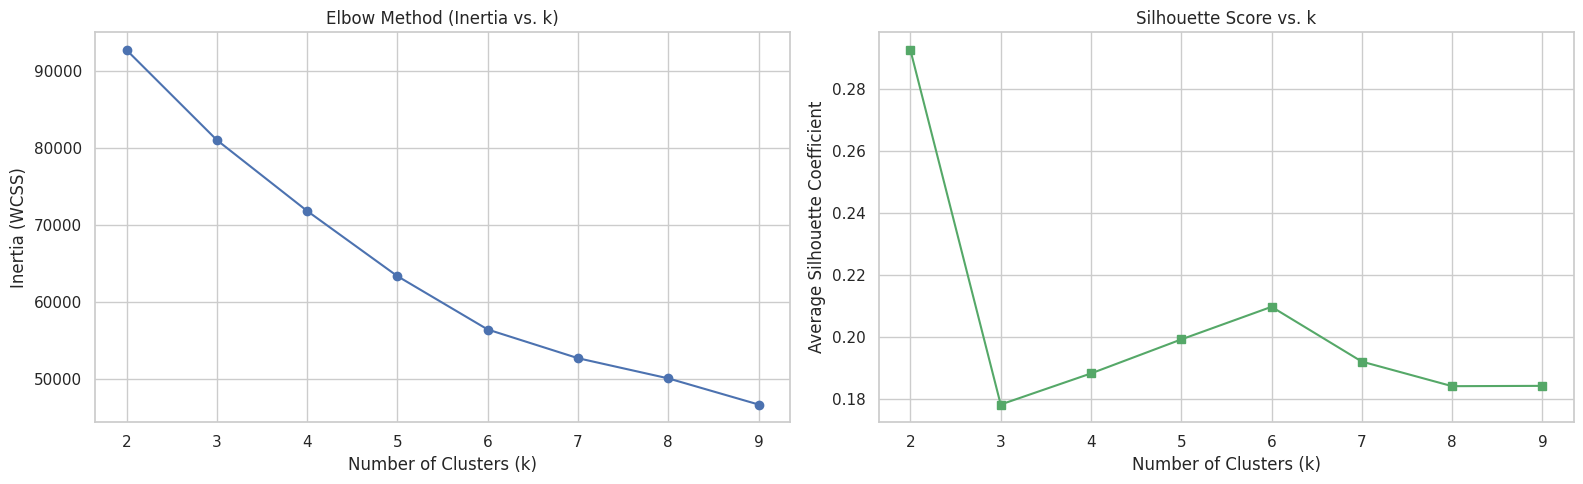

In [12]:
# YOUR CODE HERE
# Range of k values to test
k_range = range(2, 10)

inertia_list = []
silhouette_list = []

for k in k_range:
    # Initialize KMeans with n_clusters=k, random_state=6600, and n_init=10
    kmeans = KMeans(n_clusters=k, random_state=6600, n_init=10)

    # Fit model on X_demo and predict cluster labels
    labels = kmeans.fit_predict(X_sample)

    # Append the inertia_ attribute to inertia_list
    inertia_list.append(kmeans.inertia_)

    # Compute silhouette_score(X_demo, labels) and append to silhouette_list
    score = silhouette_score(X_sample, labels)
    silhouette_list.append(score)

# Plotting the diagnostic curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Elbow Curve (Inertia)
axes[0].plot(k_range, inertia_list, marker='o', color='b')
axes[0].set_title("Elbow Method (Inertia vs. k)")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (WCSS)")

# Plot 2: Silhouette Scores
axes[1].plot(k_range, silhouette_list, marker='s', color='g')
axes[1].set_title("Silhouette Score vs. k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Average Silhouette Coefficient")

plt.tight_layout()
plt.show()

I noticed that the X_sample dataframe was built from the raw data, but I think that might have been a mistake, since we scaled the data earlier, so I changed the X_sample df to be constructed from the scaled dataset made earlier (df_music_scaled).

The resulting inertia and silhouette scores for the various values of $k$ are interesting! The silhouette score is highest at $k=2$, which seems to mean that the samples could be separated pretty effectively into 2 groups. The $s(i)$ the drops dramatically at $k=3$ and then peaks again at $k=6$.

In the inertia elbow plot, there does seem to be a little bit of a steeper bend in the curve at $k=6$ compared to other points, so that makes it seem like 6 clusters would be a reasonable number to separate the observations into.

# Explore these different samples a bit. How would you describe them? What would you name them?

In [15]:
# YOUR EXPLORATION HERE

#clustering observations into 6 clusters
kmeans = KMeans(n_clusters=6, random_state=6600)
clusters = kmeans.fit_predict(X_sample)

#examining the center of the clusters
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X_sample.columns
)

#examining centers of each cluster relative to each other with colors
cluster_centers.style.background_gradient(
    cmap='RdBu',
    axis=0
)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,valence,tempo
0,-0.199874,0.477485,0.454079,-0.207054,-0.672602,-0.415264,-0.486512,-0.360130
1,0.871983,0.280111,0.301406,0.513009,-0.147420,-0.453774,0.927390,-0.276168
2,-1.255958,-1.855799,-2.571690,-0.299687,1.655046,2.094679,-1.095615,-0.662906
3,0.100272,0.396971,-0.027409,-0.118032,-0.605723,2.075341,-0.479027,0.163938
4,-0.440502,0.669115,0.559614,0.130067,-0.549411,-0.419282,0.185310,1.361428
5,-0.257592,-1.102132,-0.530511,-0.327743,1.205975,-0.411987,-0.298414,-0.242073


## Initial observations:

***Cluster 0*** has

*   **high** energy, loudness
*   **low** acousticness and instrumentalness

This cluster is high energy non-acoustic with vocals.

***Cluster 1*** has

*   **high** danceability, speechiness and valence
*   **low** instrumentalness

Danceable, positive, non-acoustic and speech characteristics.


***Cluster 2*** exhibits the

*   **high** acousticness and interumentalness
*   **low** danceability, energy, loudness, valence, tempo

This one is very instrumental with low energy, valence and tempo. It sounds like sad instrumental music.
:

***Cluster 3*** has

*   **high** energy, instrumentalness
*   **low** acousticness

This cluster is instrumental but not acoustic, energetic and relatively loud.

***Cluster 4*** has

*   **highish** accousticness
*   **low** speechiness, instrumentalness, and tempo

So slower, acoustic music with vocals. Like a guy singing to guitar music, maybe?

***Cluster 5*** has

*   **highest** energy, loudness, tempo
*   **low** acousticness, instrumentalness

This is loud, fast, non-acoustic and lots of vocals. Sounds like a lot of pop music these days (which could be from various genres: rock, country, etc.)

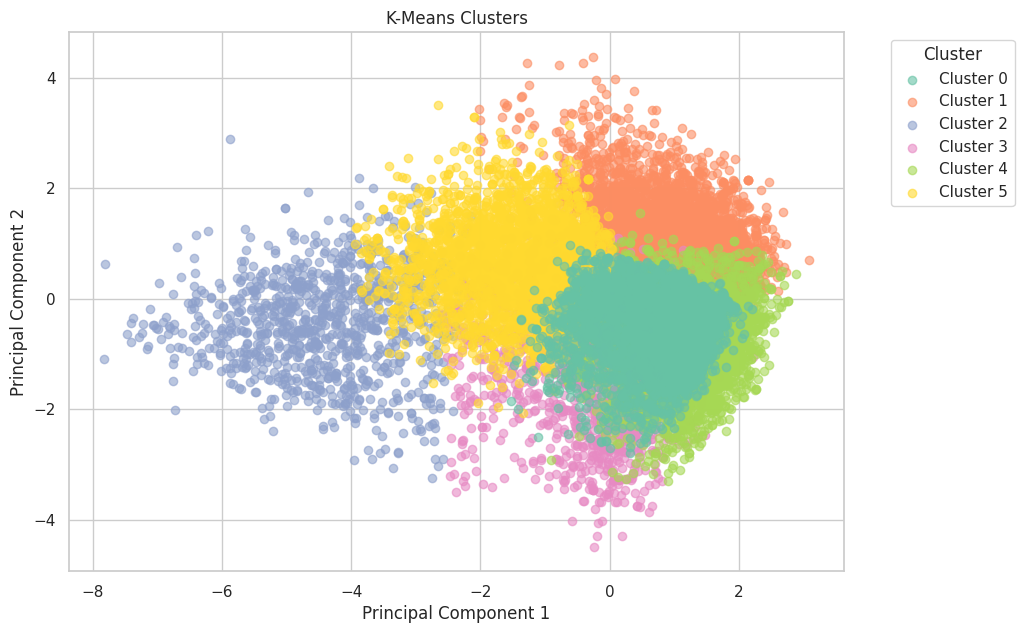

array([0.35290803, 0.17319524])

In [30]:

#looking at the clusters visually using PCA

# reducing data down to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

# plotting observations, colored by assigned cluster
plt.figure(figsize=(10, 7))

cmap = plt.get_cmap('Set2')

for cluster in range(kmeans.n_clusters):
    plt.scatter(
        X_pca[kmeans.labels_ == cluster, 0],
        X_pca[kmeans.labels_ == cluster, 1],
        color=cmap(cluster),
        label=f'Cluster {cluster}',
        alpha=0.6,
        zorder=10 if cluster == 0 else 1
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters')

plt.legend(
    title='Cluster',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.show()

#looking at how much variance is captured by the PCA components
pca.explained_variance_ratio_

These clusters look nicely grouped! but the PCA variance ratio is not very high. Looks like the components together captured about half of the variance of the original dataframe. So this is a very simplified snapshot of these clusters.

In [32]:
#looking at average distances in each cluster from other cluster centers

distances = kmeans.transform(X_sample)

distance_df = pd.DataFrame(
    distances,
    columns=[f'Center {i}' for i in range(kmeans.n_clusters)]
)

distance_df['Assigned Cluster'] = kmeans.labels_

average_distances = (
    distance_df
    .groupby('Assigned Cluster')
    .mean()
)

average_distances

,Center 0,Center 1,Center 2,Center 3,Center 4,Center 5
Assigned Cluster,,,,,,
0,1.488471,2.461196,5.482722,3.022586,2.394941,3.025923
1,2.800899,1.989945,6.063210,3.770580,3.079216,3.480477
2,5.740350,6.078093,2.310230,4.944536,6.240117,4.258080
3,3.355524,3.771912,4.874397,2.085906,3.644684,4.096281
4,2.538076,2.878569,6.080110,3.457198,1.716148,3.655155
5,3.161241,3.288340,4.031621,3.942330,3.652466,1.788270


The smallest distances should be along the diagonals, since it's each clusters own assigned cluster. And that does indeed seem to be the case.

Looking at these relationships visually:

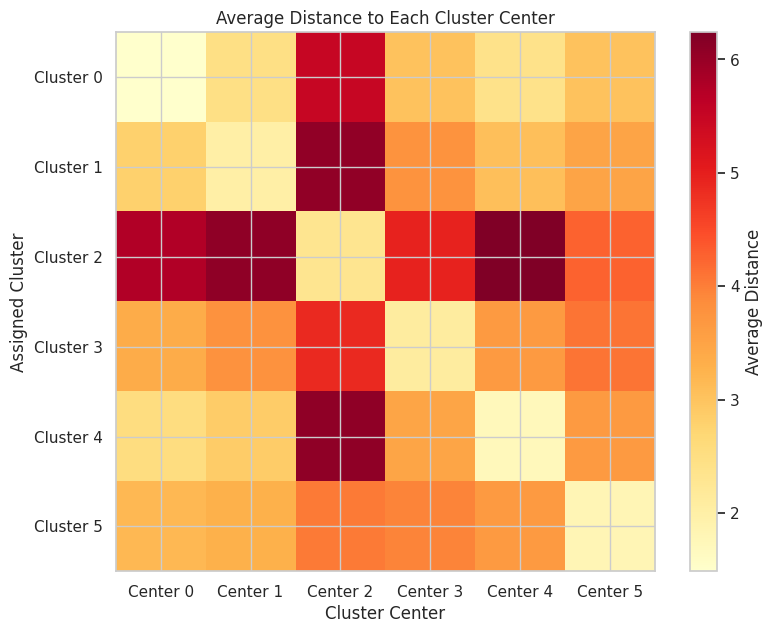

In [33]:
#showing relationships between clusters with a heatmap
plt.figure(figsize=(9, 7))

plt.imshow(average_distances, cmap='YlOrRd')

plt.colorbar(label='Average Distance')

plt.xticks(
    range(kmeans.n_clusters),
    [f'Center {i}' for i in range(kmeans.n_clusters)]
)

plt.yticks(
    range(kmeans.n_clusters),
    [f'Cluster {i}' for i in range(kmeans.n_clusters)]
)

plt.xlabel('Cluster Center')
plt.ylabel('Assigned Cluster')
plt.title('Average Distance to Each Cluster Center')

plt.show()

This shows:

* clusters 1 and 2 are relatively different from one another
* clusters 2 and 4 are also different


* clusters 0, 1 and 4 are most similar

## Names for the clusters:

**Cluster 0** Dark and Energetic

**Cluster 1** Upbeat and Danceable

**Cluster 2** Moody Acoustic Instrumental

**Cluster 3** Loud, Danceable Electronic

**Cluster 4** Slow Acoustic

**Cluster 6** High Energy Lyrical

Once complete, please share this notebook with me (dylanzwick@weber.edu). **There is no need to notify me.** After sharing, please paste this URL into the assignment on Canvas. Thank you!